In [ ]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# B5 — Maintenance prédictive : chargement du Gold dataset

Chargement de `gold_dataset_20260622-080603.parquet` (dossier `indusense/`, en dehors de ce projet).

In [ ]:
from pathlib import Path

import pandas as pd

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 160)

GOLD_FILE = Path('../indusense/gold_dataset_20260622-080603.parquet')

In [ ]:
gold = pd.read_parquet(GOLD_FILE)

print('Shape :', gold.shape)
gold.head()

Shape : (134280, 100)


,machine_id_std,window_start,temp_mean_1h,temp_max_1h,pressure_mean_1h,pressure_max_1h,voltage_mean_1h,voltage_max_1h,rotation_mean_1h,rotation_max_1h,pieces_produced_sum_1h,window_end,temp_mean_6h,temp_max_6h,temp_std_6h,pressure_mean_6h,pressure_max_6h,pressure_std_6h,voltage_mean_6h,voltage_max_6h,...,type_surchauffe_count_prev_24h,type_baisse_pression_count_prev_24h,type_vibration_count_prev_24h,type_bruit_mecanique_count_prev_24h,type_surconsommation_count_prev_24h,type_blocage_mecanique_count_prev_24h,type_alarme_capteur_count_prev_24h,type_arret_urgence_count_prev_24h,type_defaut_qualite_count_prev_24h,days_since_last_maintenance,maintenance_count_prev_30d,future_incident_count_6h,label_failure_next_6h,future_incident_count_12h,label_failure_next_12h,future_incident_count_24h,label_failure_next_24h,future_incident_count_48h,label_failure_next_48h,split_set
0,MACH-01,2025-06-01 00:00:00,46.340,46.340,198.203,198.203,227.568,227.568,1541.787,1541.787,4,2025-06-01 01:00:00,46.3400,46.340,NaN,198.2030,198.203,NaN,227.568000,227.568,...,0,0,0,0,0,0,0,0,0,NaN,0,0.0,False,0.0,False,0.0,False,0.0,False,train
1,MACH-01,2025-06-01 01:00:00,48.762,48.762,198.295,198.295,227.480,227.480,1537.860,1537.860,4,2025-06-01 02:00:00,47.5510,48.762,1.712613,198.2490,198.295,0.065054,227.524000,227.568,...,0,0,0,0,0,0,0,0,0,NaN,0,0.0,False,0.0,False,0.0,False,0.0,False,train
2,MACH-01,2025-06-01 02:00:00,51.352,51.352,199.545,199.545,228.680,228.680,1584.660,1584.660,13,2025-06-01 03:00:00,48.8180,51.352,2.506469,198.6810,199.545,0.749659,227.909333,228.680,...,0,0,0,0,0,0,0,0,0,NaN,0,0.0,False,0.0,False,0.0,False,0.0,False,train
3,MACH-01,2025-06-01 03:00:00,49.512,49.512,201.641,201.641,228.440,228.440,1588.960,1588.960,10,2025-06-01 04:00:00,48.9915,51.352,2.075733,199.4210,201.641,1.601580,228.042000,228.680,...,0,0,0,0,0,0,0,0,0,NaN,0,0.0,False,0.0,False,0.0,False,0.0,False,train
4,MACH-01,2025-06-01 04:00:00,51.982,51.982,200.157,200.157,227.840,227.840,1548.660,1548.660,6,2025-06-01 05:00:00,49.5896,51.982,2.240562,199.5682,201.641,1.425529,228.001600,228.680,...,0,0,0,0,0,0,0,0,0,NaN,0,0.0,False,0.0,False,0.0,False,0.0,False,train


In [ ]:
gold = gold.sort_values(['machine_id_std', 'window_start']).reset_index(drop=True)

gold[['machine_id_std', 'window_start']].head()

,machine_id_std,window_start
0,MACH-01,2025-06-01 00:00:00
1,MACH-01,2025-06-01 01:00:00
2,MACH-01,2025-06-01 02:00:00
3,MACH-01,2025-06-01 03:00:00
4,MACH-01,2025-06-01 04:00:00


- Choisir un **horizon** (ex. `label_failure_next_24h`) et construire la cible `y` (0/1).

On construit le "vecteur" des valeurs à prédire :

In [ ]:
y = gold['label_failure_next_24h'].copy()

y.value_counts(normalize=True)

label_failure_next_24h
False    0.832082
True     0.167918
Name: proportion, dtype: float64

In [ ]:
dropped_cols = [c for c in gold.columns if c.startswith('future_') or '_next_' in c]
dropped_cols += ['window_start', 'window_end']
gold = gold.drop(columns=dropped_cols)

print(f'Colonnes supprimées ({len(dropped_cols)}) :', dropped_cols)
print('Shape :', gold.shape)

Colonnes supprimées (10) : ['future_incident_count_6h', 'label_failure_next_6h', 'future_incident_count_12h', 'label_failure_next_12h', 'future_incident_count_24h', 'label_failure_next_24h', 'future_incident_count_48h', 'label_failure_next_48h', 'window_start', 'window_end']
Shape : (134280, 90)


In [ ]:
gold = gold.iloc[1:].reset_index(drop=True)
y = y.iloc[1:].reset_index(drop=True)

print('Shape :', gold.shape, '| y :', y.shape)
gold.head()

Shape : (134279, 90) | y : (134279,)


,machine_id_std,temp_mean_1h,temp_max_1h,pressure_mean_1h,pressure_max_1h,voltage_mean_1h,voltage_max_1h,rotation_mean_1h,rotation_max_1h,pieces_produced_sum_1h,temp_mean_6h,temp_max_6h,temp_std_6h,pressure_mean_6h,pressure_max_6h,pressure_std_6h,voltage_mean_6h,voltage_max_6h,voltage_std_6h,rotation_mean_6h,...,type_baisse_pression,type_vibration,type_bruit_mecanique,type_surconsommation,type_blocage_mecanique,type_alarme_capteur,type_arret_urgence,type_defaut_qualite,type_surchauffe_count_prev_24h,type_baisse_pression_count_prev_24h,type_vibration_count_prev_24h,type_bruit_mecanique_count_prev_24h,type_surconsommation_count_prev_24h,type_blocage_mecanique_count_prev_24h,type_alarme_capteur_count_prev_24h,type_arret_urgence_count_prev_24h,type_defaut_qualite_count_prev_24h,days_since_last_maintenance,maintenance_count_prev_30d,split_set
0,MACH-01,48.762,48.762,198.295,198.295,227.48,227.48,1537.86,1537.86,4,47.5510,48.762,1.712613,198.249000,198.295,0.065054,227.524000,227.568,0.062225,1539.823500,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,0,train
1,MACH-01,51.352,51.352,199.545,199.545,228.68,228.68,1584.66,1584.66,13,48.8180,51.352,2.506469,198.681000,199.545,0.749659,227.909333,228.680,0.668866,1554.769000,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,0,train
2,MACH-01,49.512,49.512,201.641,201.641,228.44,228.44,1588.96,1588.96,10,48.9915,51.352,2.075733,199.421000,201.641,1.601580,228.042000,228.680,0.607170,1563.316750,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,0,train
3,MACH-01,51.982,51.982,200.157,200.157,227.84,227.84,1548.66,1548.66,6,49.5896,51.982,2.240562,199.568200,201.641,1.425529,228.001600,228.680,0.533529,1560.385400,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,0,train
4,MACH-01,50.402,50.402,199.914,199.914,227.50,227.50,1554.76,1554.76,4,49.7250,51.982,2.031279,199.625833,201.641,1.282824,227.918000,228.680,0.519284,1559.447833,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,0,train


- Utiliser le **split temporel fourni** (`split_set` : train < validation < test) — **pas** de split aléatoire.

On sépare `X` (features) et `y` en train / validation / test à partir de la colonne `split_set` :

In [ ]:
X = gold.drop(columns='split_set')

train_mask = gold['split_set'] == 'train'
val_mask = gold['split_set'] == 'validation'
test_mask = gold['split_set'] == 'test'

X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_val, y_val = X.loc[val_mask], y.loc[val_mask]
X_test, y_test = X.loc[test_mask], y.loc[test_mask]

for name, split_X in [('train', X_train), ('validation', X_val), ('test', X_test)]:
    print(f'{name:<12} {split_X.shape[0]:>7} lignes')

train          93989 lignes
validation     20145 lignes
test           20145 lignes


- Imputer les `NaN` (médiane) ; standardiser pour les modèles linéaires.

In [ ]:
# on liste les colonnes avec des valeurs à NaN

nan_counts = X.isna().sum()
nan_counts = nan_counts[nan_counts > 0].sort_values(ascending=False)

print(f'Colonnes avec des NaN ({len(nan_counts)}/{X.shape[1]}) :')
nan_counts

Colonnes avec des NaN (43/89) :


incident_max_severity_1h          133237
incident_max_severity_prev_24h    111711
hours_since_last_incident           4027
days_since_last_maintenance         3445
rotation_trend_6h                   1722
rotation_delta_3h                   1360
rotation_delta_1h                   1085
rotation_max_1h                      948
rotation_mean_1h                     948
rotation_std_6h                      576
rotation_mean_6h                     350
rotation_max_6h                      350
pressure_trend_6h                    115
temp_trend_6h                         99
voltage_trend_6h                      89
rotation_std_12h                      82
pressure_delta_3h                     64
temp_delta_3h                         52
voltage_delta_3h                      44
pressure_delta_1h                     30
pressure_std_6h                       22
temp_delta_1h                         20
temp_zscore_24h                       19
rotation_max_12h                      18
rotation_mean_12

On impute donc avec la médiane :
hours_since_last_incident           4027
days_since_last_maintenance         3445
rotation_trend_6h                   1722
rotation_delta_3h                   1360
rotation_delta_1h                   1085
rotation_max_1h                      948
rotation_mean_1h                     948
rotation_std_6h                      576
rotation_mean_6h                     350
rotation_max_6h                      350
pressure_trend_6h                    115
temp_trend_6h                         99
voltage_trend_6h                      89
rotation_std_12h                      82
pressure_delta_3h                     64
temp_delta_3h                         52
voltage_delta_3h                      44
pressure_delta_1h                     30
pressure_std_6h                       22
temp_delta_1h                         20
temp_zscore_24h                       19
rotation_max_12h                      18
rotation_mean_12h                     18
temp_std_6h                           16
pressure_zscore_machine               14
voltage_delta_1h                      14
pressure_std_24h                      14
rotation_std_24h                      14
voltage_std_24h                       14
temp_std_24h                          14
voltage_std_12h                       14
pressure_std_12h                      14
temp_std_12h                          14
voltage_std_6h                        14
pressure_max_1h                       14
pressure_mean_1h                      14
temp_max_1h                            5
temp_zscore_machine                    5
temp_mean_1h                           5
pressure_max_6h                        4
pressure_mean_6h                       4

et avec 0 :
incident_max_severity_1h          133237
incident_max_severity_prev_24h    111711


In [ ]:
# imputation pour chaque set

zero_cols = ['incident_max_severity_1h', 'incident_max_severity_prev_24h']
median_cols = [c for c in nan_counts.index if c not in zero_cols]

medians = X_train[median_cols].median()

for split in (X_train, X_val, X_test):
    split[median_cols] = split[median_cols].fillna(medians)
    split[zero_cols] = split[zero_cols].fillna(0)

print('NaN restants — train :', X_train.isna().sum().sum())
print('NaN restants — val   :', X_val.isna().sum().sum())
print('NaN restants — test  :', X_test.isna().sum().sum())

NaN restants — train : 0
NaN restants — val   : 0
NaN restants — test  : 0


/var/folders/7v/dfg0p2vj1z58n65d99l2n1lh0000gp/T/ipykernel_70221/1312610336.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  split[median_cols] = split[median_cols].fillna(medians)
/var/folders/7v/dfg0p2vj1z58n65d99l2n1lh0000gp/T/ipykernel_70221/1312610336.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  split[zero_cols] = split[zero_cols].fillna(0)
/var/folders/7v/dfg0p2vj1z58n65d99l2n1lh0000gp/T/ipykernel_70221/1312610336.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a sli

### 2. Gérer le déséquilibre
- Vérifier le taux de panne (rare) → **ne pas utiliser l'accuracy**.

In [ ]:
for name, split_y in [('train', y_train), ('validation', y_val), ('test', y_test)]:
    rate = split_y.mean()
    print(f'{name:<12} taux de panne : {rate:.2%}  ({split_y.sum()}/{len(split_y)})')

train        taux de panne : 16.60%  (15598/93989)
validation   taux de panne : 17.24%  (3472/20145)
test         taux de panne : 17.26%  (3478/20145)


- Compenser : `class_weight="balanced"` (scikit-learn) et `scale_pos_weight` (XGBoost, calculé sur le train).

=> OK, les % sont à 16.60 (train) / 17.24 (validation) et 17.26 (test)

### 3. Entraîner trois modèles (du plus simple au plus expressif)
- **Régression logistique** — baseline linéaire (Pipeline : imputation → standardisation → modèle).

Doc : [`sklearn.linear_model.LogisticRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

feature_cols = X_train.select_dtypes(include='number').columns

log_reg = make_pipeline(
    StandardScaler(),
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
)
log_reg.fit(X_train[feature_cols], y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[bool](2,)","[False, True]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](88,)","['temp_mean_1h','temp_max_1h','pressure_mean_1h',..., 'type_defaut_qualite_count_prev_24h','days_since_last_maintenance', 'maintenance_count_prev_30d']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,88
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


- **Random Forest** — non linéaire, robuste.

Doc : [`sklearn.ensemble.RandomForestClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42,
)
rf.fit(X_train[feature_cols], y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

- **XGBoost** — gradient boosting, candidat principal (HP sobres, à optimiser en B7).

Doc : [`xgboost.XGBClassifier`](https://xgboost.readthedocs.io/en/stable/python/python_api.html#xgboost.XGBClassifier) — [paramètres](https://xgboost.readthedocs.io/en/stable/parameter.html)


In [ ]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == False).sum() / (y_train == True).sum()

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    n_jobs=-1,
    random_state=42,
)
xgb.fit(X_train[feature_cols], y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


### 4. Évaluer et comparer
- Métriques : Choisir une métrique adaptée au problème
- **Validation croisée temporelle** (`TimeSeriesSplit`) pour une estimation robuste.
- Choisir un **seuil de décision** et lire la **matrice de confusion** (faux négatifs vs faux positifs).

In [ ]:
from sklearn.base import clone
from sklearn.metrics import average_precision_score
from sklearn.model_selection import TimeSeriesSplit

models = {
    'Régression logistique': log_reg,
    'Random Forest': rf,
    'XGBoost': xgb,
}

# window_start a été droppé de `gold` : on le recalcule, aligné sur le même
# tri + la même ligne supprimée, pour ordonner X_train chronologiquement
# (toutes machines confondues) avant le split temporel.
window_start_full = (
    pd.read_parquet(GOLD_FILE)
    .sort_values(['machine_id_std', 'window_start'])['window_start']
    .reset_index(drop=True)
    .iloc[1:]
    .reset_index(drop=True)
)

chrono_order = window_start_full.loc[X_train.index].sort_values().index
X_train_ts = X_train.loc[chrono_order]
y_train_ts = y_train.loc[chrono_order]

tscv = TimeSeriesSplit(n_splits=5)
cv_scores = {name: [] for name in models}

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_ts), start=1):
    X_fold_train = X_train_ts.iloc[train_idx][feature_cols]
    y_fold_train = y_train_ts.iloc[train_idx]
    X_fold_val = X_train_ts.iloc[val_idx][feature_cols]
    y_fold_val = y_train_ts.iloc[val_idx]

    for name, fitted_model in models.items():
        model = clone(fitted_model)
        model.fit(X_fold_train, y_fold_train)
        proba = model.predict_proba(X_fold_val)[:, 1]
        cv_scores[name].append(average_precision_score(y_fold_val, proba))

cv_summary = pd.DataFrame({
    'Modèle': cv_scores.keys(),
    'PR-AUC moyen (CV)': [pd.Series(s).mean() for s in cv_scores.values()],
    'Écart-type (CV)': [pd.Series(s).std() for s in cv_scores.values()],
}).sort_values('PR-AUC moyen (CV)', ascending=False).reset_index(drop=True)
cv_summary

,Modèle,PR-AUC moyen (CV),Écart-type (CV)
0,Random Forest,0.572296,0.089559
1,Régression logistique,0.570661,0.079467
2,XGBoost,0.540353,0.073888


               Modèle  Vrai Négatif  Faux Positif  Faux Négatif  Vrai Positif
Régression logistique         15333          1340          1724          1748
        Random Forest         16442           231          2095          1377
              XGBoost         15632          1041          1823          1649


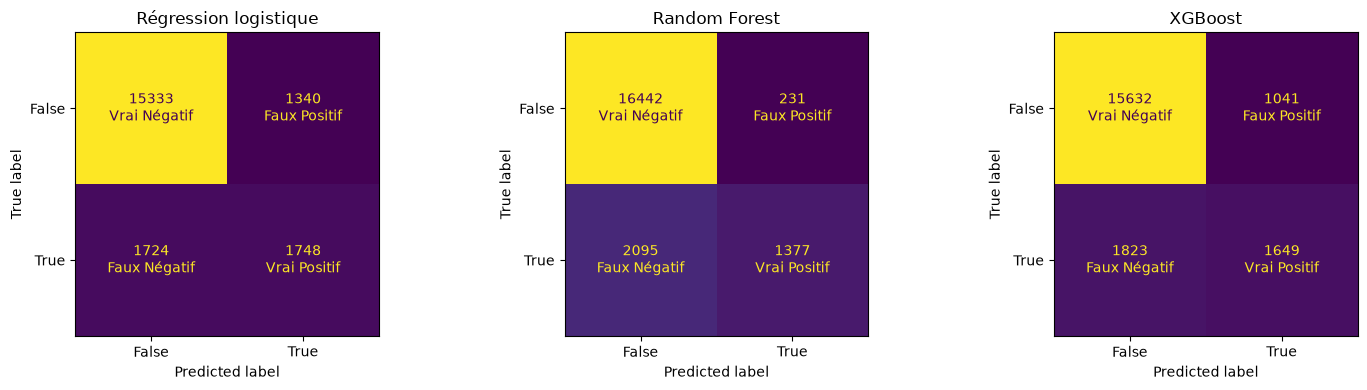

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

predictions = {name: model.predict(X_val[feature_cols]) for name, model in models.items()}

cm_table = pd.DataFrame([
    {'Modèle': name, 'Vrai Négatif': tn, 'Faux Positif': fp, 'Faux Négatif': fn, 'Vrai Positif': tp}
    for name, pred in predictions.items()
    for tn, fp, fn, tp in [confusion_matrix(y_val, pred).ravel()]
])
print(cm_table.to_string(index=False))

quadrant_labels = [['Vrai Négatif', 'Faux Positif'], ['Faux Négatif', 'Vrai Positif']]

fig, axes = plt.subplots(1, len(models), figsize=(15, 4))

for ax, (name, pred) in zip(axes, predictions.items()):
    disp = ConfusionMatrixDisplay.from_predictions(y_val, pred, ax=ax, colorbar=False)
    for i in range(2):
        for j in range(2):
            value = disp.text_[i, j].get_text()
            disp.text_[i, j].set_text(f'{value}\n{quadrant_labels[i][j]}')
    ax.set_title(name)

plt.tight_layout()
plt.show()

### 5. Suivre et sélectionner
- Journaliser paramètres et métriques dans **MLflow** (backend SQLite local).

In [ ]:
import mlflow

mlflow.set_tracking_uri('sqlite:///mlflow.db')
mlflow.set_experiment('b5-maintenance-predictive')



<Experiment: artifact_location='/Users/kenji/formation-ia/indusense_tp/mlruns/1', creation_time=1783348812053, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1783348812053, lifecycle_stage='active', name='b5-maintenance-predictive', tags={}, trace_location=None, workspace='default'>

On journalise un run "baseline" par modèle : hyperparamètres tels que fixés dans les cellules de fit + métriques calculées sur la validation.

In [ ]:
import mlflow.sklearn
import mlflow.xgboost
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

model_params = {
    'Régression logistique': {
        'class_weight': 'balanced', 'max_iter': 1000, 'random_state': 42,
    },
    'Random Forest': {
        'n_estimators': 300, 'class_weight': 'balanced', 'n_jobs': -1, 'random_state': 42,
    },
    'XGBoost': {
        'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1,
        'scale_pos_weight': scale_pos_weight, 'random_state': 42,
    },
}

for name, model in models.items():
    proba = model.predict_proba(X_val[feature_cols])[:, 1]
    pred = model.predict(X_val[feature_cols])
    with mlflow.start_run(run_name=f'baseline_{name}'):
        mlflow.set_tag('stage', 'baseline')
        mlflow.set_tag('model_name', name)
        mlflow.log_params(model_params[name])
        mlflow.log_metrics({
            'pr_auc': average_precision_score(y_val, proba),
            'roc_auc': roc_auc_score(y_val, proba),
            'precision': precision_score(y_val, pred),
            'recall': recall_score(y_val, pred),
            'f1': f1_score(y_val, pred),
        })
        if name == 'XGBoost':
            mlflow.xgboost.log_model(model, name='model')
        else:
            mlflow.sklearn.log_model(model, name='model')
        print(f'Run loggé pour {name}')

2026/07/07 12:15:14 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/kenji/formation-ia/indusense_tp
2026/07/07 12:15:14 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/kenji/formation-ia/indusense_tp
2026/07/07 12:15:14 INFO mlflow.utils.environment: Detected uv project at /Users/kenji/formation-ia/indusense_tp. Attempting to export requirements via 'uv export'.
2026/07/07 12:15:14 INFO mlflow.utils.uv_utils: Exported 95 dependencies via uv
2026/07/07 12:15:14 INFO mlflow.utils.environment: Successfully exported 95 requirements from uv project. Skipping package capture based inference.
2026/07/07 12:15:14 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Run loggé pour Régression logistique


2026/07/07 12:15:15 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/kenji/formation-ia/indusense_tp
2026/07/07 12:15:15 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/kenji/formation-ia/indusense_tp
2026/07/07 12:15:15 INFO mlflow.utils.environment: Detected uv project at /Users/kenji/formation-ia/indusense_tp. Attempting to export requirements via 'uv export'.
2026/07/07 12:15:15 INFO mlflow.utils.uv_utils: Exported 95 dependencies via uv
2026/07/07 12:15:15 INFO mlflow.utils.environment: Successfully exported 95 requirements from uv project. Skipping package capture based inference.
2026/07/07 12:15:15 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/07/07 12:15:15 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/kenji/formation-ia/indusense_t

Run loggé pour Random Forest


2026/07/07 12:15:16 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Run loggé pour XGBoost


### Expérimentation : Random Forest à 100 arbres
Même config que la baseline mais `n_estimators=100` — journalisé comme run `experiment` pour comparer avec la baseline à 300 arbres.

In [ ]:
rf_100_params = {
    'n_estimators': 100, 'class_weight': 'balanced', 'n_jobs': -1, 'random_state': 42,
}
rf_100 = RandomForestClassifier(**rf_100_params)
rf_100.fit(X_train[feature_cols], y_train)

proba = rf_100.predict_proba(X_val[feature_cols])[:, 1]
pred = rf_100.predict(X_val[feature_cols])

with mlflow.start_run(run_name='experiment_Random Forest 100 arbres'):
    mlflow.set_tag('stage', 'experiment')
    mlflow.set_tag('model_name', 'Random Forest (100 arbres)')
    mlflow.log_params(rf_100_params)
    mlflow.log_metrics({
        'pr_auc': average_precision_score(y_val, proba),
        'roc_auc': roc_auc_score(y_val, proba),
        'precision': precision_score(y_val, pred),
        'recall': recall_score(y_val, pred),
        'f1': f1_score(y_val, pred),
    })
    mlflow.sklearn.log_model(rf_100, name='model')
    print('Run loggé pour Random Forest (100 arbres)')

2026/07/07 12:15:24 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/kenji/formation-ia/indusense_tp
2026/07/07 12:15:25 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/kenji/formation-ia/indusense_tp
2026/07/07 12:15:25 INFO mlflow.utils.environment: Detected uv project at /Users/kenji/formation-ia/indusense_tp. Attempting to export requirements via 'uv export'.
2026/07/07 12:15:25 INFO mlflow.utils.uv_utils: Exported 95 dependencies via uv
2026/07/07 12:15:25 INFO mlflow.utils.environment: Successfully exported 95 requirements from uv project. Skipping package capture based inference.
2026/07/07 12:15:25 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Run loggé pour Random Forest (100 arbres)


### Expérimentation : XGBoost + GridSearchCV
Recherche sur une petite grille d'hyperparamètres, scorée en PR-AUC avec la validation croisée temporelle (`TimeSeriesSplit`), puis journalisation du meilleur modèle dans MLflow.

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
}

scoring = {
    'pr_auc': 'average_precision',
    'roc_auc': 'roc_auc',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
}

grid_search = GridSearchCV(
    XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric='aucpr',
        n_jobs=-1,
        random_state=42,
    ),
    param_grid,
    scoring=scoring,
    refit='pr_auc',  # le "meilleur" modèle reste choisi sur la PR-AUC
    cv=tscv,  # validation croisée temporelle, sur le train ordonné chronologiquement
    n_jobs=-1,
)
grid_search.fit(X_train_ts[feature_cols], y_train_ts)

print('Meilleurs paramètres :', grid_search.best_params_)
print(f'PR-AUC moyen (CV) : {grid_search.best_score_:.4f}')

xgb_best = grid_search.best_estimator_
proba = xgb_best.predict_proba(X_val[feature_cols])[:, 1]
pred = xgb_best.predict(X_val[feature_cols])

cv_results = grid_search.cv_results_

with mlflow.start_run(run_name='experiment_XGBoost_GridSearchCV'):
    mlflow.set_tag('stage', 'experiment')
    mlflow.set_tag('model_name', 'XGBoost (GridSearchCV)')
    mlflow.log_params({**grid_search.best_params_, 'scale_pos_weight': scale_pos_weight, 'random_state': 42})
    mlflow.log_metrics({
        'pr_auc': average_precision_score(y_val, proba),
        'roc_auc': roc_auc_score(y_val, proba),
        'precision': precision_score(y_val, pred),
        'recall': recall_score(y_val, pred),
        'f1': f1_score(y_val, pred),
        'cv_pr_auc': grid_search.best_score_,
    })
    mlflow.xgboost.log_model(xgb_best, name='model')

    # un run enfant par combinaison de la grille, avec ses scores CV (moyennes sur les folds)
    for i, params in enumerate(cv_results['params']):
        combo = ', '.join(f'{k}={v}' for k, v in params.items())
        with mlflow.start_run(run_name=f'gridsearch_XGBoost ({combo})', nested=True):
            mlflow.set_tag('stage', 'gridsearch')
            mlflow.log_params(params)
            mlflow.log_metrics({
                **{f'cv_{name}': cv_results[f'mean_test_{name}'][i] for name in scoring},
                'cv_pr_auc_std': cv_results['std_test_pr_auc'][i],
                'cv_rank': cv_results['rank_test_pr_auc'][i],
            })

    print(f'Run loggé pour XGBoost (GridSearchCV) + {len(cv_results["params"])} runs enfants (1 par combinaison)')

2026/07/07 15:26:02 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/kenji/formation-ia/indusense_tp
2026/07/07 15:26:02 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/kenji/formation-ia/indusense_tp
2026/07/07 15:26:02 INFO mlflow.utils.environment: Detected uv project at /Users/kenji/formation-ia/indusense_tp. Attempting to export requirements via 'uv export'.


Meilleurs paramètres : {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
PR-AUC moyen (CV) : 0.5693


2026/07/07 15:26:02 INFO mlflow.utils.uv_utils: Exported 95 dependencies via uv
2026/07/07 15:26:02 INFO mlflow.utils.environment: Successfully exported 95 requirements from uv project. Skipping package capture based inference.
2026/07/07 15:26:02 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Run loggé pour XGBoost (GridSearchCV) + 12 runs enfants (1 par combinaison)


### Expérimentation : XGBoost avec max_depth à 3


In [ ]:
scale_pos_weight = (y_train == False).sum() / (y_train == True).sum()

xgb_md3_params = {
        'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1,
        'scale_pos_weight': scale_pos_weight, 'random_state': 42,
    }
xgb_dw3 = XGBClassifier(**xgb_md3_params)
xgb_dw3.fit(X_train[feature_cols], y_train)

proba = xgb_dw3.predict_proba(X_val[feature_cols])[:, 1]
pred = xgb_dw3.predict(X_val[feature_cols])

with mlflow.start_run(run_name='experiment_XGBoosta max depth 3'):
    mlflow.set_tag('stage', 'experiment')
    mlflow.set_tag('model_name', 'XGBoost max depth 3')
    mlflow.log_params(xgb_md3_params)
    mlflow.log_metrics({
        'pr_auc': average_precision_score(y_val, proba),
        'roc_auc': roc_auc_score(y_val, proba),
        'precision': precision_score(y_val, pred),
        'recall': recall_score(y_val, pred),
        'f1': f1_score(y_val, pred),
    })
    mlflow.sklearn.log_model(xgb_md3_params, name='model')
    print('Run loggé pour XGBoost max depth 3')

2026/07/07 12:30:17 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/kenji/formation-ia/indusense_tp
2026/07/07 12:30:17 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/07/07 12:30:17 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/kenji/formation-ia/indusense_tp
2026/07/07 12:30:17 INFO mlflow.utils.environment: Detected uv project at /Users/kenji/formation-ia/indusense_tp. Attempting to export requirements via 'uv export'.
2026/07/07 12:30:17 INFO mlflow.utils.uv_utils: Exported 95 dependencies via uv
2026/07/07 12:30:17 INFO mlflow.utils.environment: Successfully exported 95 requirements from uv project. Skipping package capture based inference.
2026/07/07 12:30:18 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Run loggé pour XGBoost max depth 3


### Expérimentation : Régression logistique + GridSearchCV
Même démarche que pour XGBoost : grille sur la régularisation `C` (le pipeline scaler + modèle est cloné par la grille), scores multi-métriques en CV temporelle, un run enfant par combinaison.

In [ ]:
logreg_param_grid = {
    'logisticregression__C': [0.01, 0.1, 1, 10],
    'logisticregression__class_weight': ['balanced', None],
}

logreg_grid = GridSearchCV(
    make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000, random_state=42),
    ),
    logreg_param_grid,
    scoring=scoring,
    refit='pr_auc',
    cv=tscv,
    n_jobs=-1,
)
logreg_grid.fit(X_train_ts[feature_cols], y_train_ts)

print('Meilleurs paramètres :', logreg_grid.best_params_)
print(f'PR-AUC moyen (CV) : {logreg_grid.best_score_:.4f}')

logreg_best = logreg_grid.best_estimator_
proba = logreg_best.predict_proba(X_val[feature_cols])[:, 1]
pred = logreg_best.predict(X_val[feature_cols])

cv_results = logreg_grid.cv_results_

# on retire le préfixe "logisticregression__" ajouté par le pipeline pour la lisibilité
strip = lambda params: {k.removeprefix('logisticregression__'): v for k, v in params.items()}

with mlflow.start_run(run_name='experiment_LogReg_GridSearchCV'):
    mlflow.set_tag('stage', 'experiment')
    mlflow.set_tag('model_name', 'Régression logistique (GridSearchCV)')
    mlflow.log_params({**strip(logreg_grid.best_params_), 'max_iter': 1000, 'random_state': 42})
    mlflow.log_metrics({
        'pr_auc': average_precision_score(y_val, proba),
        'roc_auc': roc_auc_score(y_val, proba),
        'precision': precision_score(y_val, pred),
        'recall': recall_score(y_val, pred),
        'f1': f1_score(y_val, pred),
        'cv_pr_auc': logreg_grid.best_score_,
    })
    mlflow.sklearn.log_model(logreg_best, name='model')

    # un run enfant par combinaison de la grille, avec ses scores CV (moyennes sur les folds)
    for i, params in enumerate(cv_results['params']):
        combo = ', '.join(f'{k}={v}' for k, v in strip(params).items())
        with mlflow.start_run(run_name=f'gridsearch_LogReg ({combo})', nested=True):
            mlflow.set_tag('stage', 'gridsearch')
            mlflow.log_params(strip(params))
            mlflow.log_metrics({
                **{f'cv_{name}': cv_results[f'mean_test_{name}'][i] for name in scoring},
                'cv_pr_auc_std': cv_results['std_test_pr_auc'][i],
                'cv_rank': cv_results['rank_test_pr_auc'][i],
            })

    print(f'Run loggé pour Régression logistique (GridSearchCV) + {len(cv_results["params"])} runs enfants')

### Expérimentation : Random Forest + GridSearchCV
Même démarche : grille sur le nombre d'arbres, la profondeur et `class_weight`, scores multi-métriques en CV temporelle, un run enfant par combinaison.

In [ ]:
rf_param_grid = {
    'n_estimators': [100, 300],
    'max_depth': [None, 10, 20],
    'class_weight': ['balanced', None],
}

rf_grid = GridSearchCV(
    RandomForestClassifier(n_jobs=-1, random_state=42),
    rf_param_grid,
    scoring=scoring,
    refit='pr_auc',
    cv=tscv,
    n_jobs=-1,
)
rf_grid.fit(X_train_ts[feature_cols], y_train_ts)

print('Meilleurs paramètres :', rf_grid.best_params_)
print(f'PR-AUC moyen (CV) : {rf_grid.best_score_:.4f}')

rf_best = rf_grid.best_estimator_
proba = rf_best.predict_proba(X_val[feature_cols])[:, 1]
pred = rf_best.predict(X_val[feature_cols])

cv_results = rf_grid.cv_results_

with mlflow.start_run(run_name='experiment_RandomForest_GridSearchCV'):
    mlflow.set_tag('stage', 'experiment')
    mlflow.set_tag('model_name', 'Random Forest (GridSearchCV)')
    mlflow.log_params({**rf_grid.best_params_, 'random_state': 42})
    mlflow.log_metrics({
        'pr_auc': average_precision_score(y_val, proba),
        'roc_auc': roc_auc_score(y_val, proba),
        'precision': precision_score(y_val, pred),
        'recall': recall_score(y_val, pred),
        'f1': f1_score(y_val, pred),
        'cv_pr_auc': rf_grid.best_score_,
    })
    mlflow.sklearn.log_model(rf_best, name='model')

    # un run enfant par combinaison de la grille, avec ses scores CV (moyennes sur les folds)
    for i, params in enumerate(cv_results['params']):
        combo = ', '.join(f'{k}={v}' for k, v in params.items())
        with mlflow.start_run(run_name=f'gridsearch_RandomForest ({combo})', nested=True):
            mlflow.set_tag('stage', 'gridsearch')
            mlflow.log_params(params)
            mlflow.log_metrics({
                **{f'cv_{name}': cv_results[f'mean_test_{name}'][i] for name in scoring},
                'cv_pr_auc_std': cv_results['std_test_pr_auc'][i],
                'cv_rank': cv_results['rank_test_pr_auc'][i],
            })

    print(f'Run loggé pour Random Forest (GridSearchCV) + {len(cv_results["params"])} runs enfants')

Meilleurs paramètres : {'class_weight': None, 'max_depth': 10, 'n_estimators': 300}
PR-AUC moyen (CV) : 0.5880


2026/07/07 16:01:52 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/kenji/formation-ia/indusense_tp
2026/07/07 16:01:53 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/kenji/formation-ia/indusense_tp
2026/07/07 16:01:53 INFO mlflow.utils.environment: Detected uv project at /Users/kenji/formation-ia/indusense_tp. Attempting to export requirements via 'uv export'.
2026/07/07 16:01:53 INFO mlflow.utils.uv_utils: Exported 95 dependencies via uv
2026/07/07 16:01:53 INFO mlflow.utils.environment: Successfully exported 95 requirements from uv project. Skipping package capture based inference.
2026/07/07 16:01:53 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Run loggé pour Random Forest (GridSearchCV) + 12 runs enfants


### Expérimentation : Random Forest + Optuna
Au lieu d'une grille exhaustive, Optuna explore l'espace d'hyperparamètres de façon adaptative (TPE) : chaque essai est scoré en PR-AUC par CV temporelle, puis journalisé comme run enfant dans MLflow — même structure que les blocs GridSearchCV.

### Optuna

In [ ]:
import optuna
from sklearn.model_selection import cross_val_score

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 400, step=50),
        'max_depth': trial.suggest_int('max_depth', 5, 30),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5]),
        'class_weight': trial.suggest_categorical('class_weight', ['balanced', None]),
    }
    scores = cross_val_score(
        RandomForestClassifier(**params, n_jobs=-1, random_state=42),
        X_train_ts[feature_cols], y_train_ts,
        scoring='average_precision',
        cv=tscv,
        n_jobs=-1,
    )
    return scores.mean()

sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective, n_trials=25, show_progress_bar=True)

print('Meilleurs paramètres :', study.best_params)
print(f'PR-AUC moyen (CV) : {study.best_value:.4f}')

# refit du meilleur modèle sur tout le train, puis évaluation sur la validation
rf_optuna = RandomForestClassifier(**study.best_params, n_jobs=-1, random_state=42)
rf_optuna.fit(X_train[feature_cols], y_train)

proba = rf_optuna.predict_proba(X_val[feature_cols])[:, 1]
pred = rf_optuna.predict(X_val[feature_cols])

with mlflow.start_run(run_name='experiment_RandomForest_Optuna'):
    mlflow.set_tag('stage', 'experiment')
    mlflow.set_tag('model_name', 'Random Forest (Optuna)')
    mlflow.log_params({**study.best_params, 'random_state': 42})
    mlflow.log_metrics({
        'pr_auc': average_precision_score(y_val, proba),
        'roc_auc': roc_auc_score(y_val, proba),
        'precision': precision_score(y_val, pred),
        'recall': recall_score(y_val, pred),
        'f1': f1_score(y_val, pred),
        'cv_pr_auc': study.best_value,
    })
    mlflow.sklearn.log_model(rf_optuna, name='model')

    # un run enfant par essai Optuna, avec son score CV
    for trial in study.trials:
        combo = ', '.join(f'{k}={v}' for k, v in trial.params.items())
        with mlflow.start_run(run_name=f'optuna_RandomForest trial {trial.number} ({combo})', nested=True):
            mlflow.set_tag('stage', 'optuna')
            mlflow.log_params(trial.params)
            mlflow.log_metrics({
                'cv_pr_auc': trial.value,
                'trial_number': trial.number,
            })

    print(f'Run loggé pour Random Forest (Optuna) + {len(study.trials)} runs enfants (1 par essai)')

[I 2026-07-07 16:08:19,538] A new study created in memory with name: no-name-1765f8e4-38ba-4184-8559-a0c585988c7e


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2026-07-07 16:09:02,761] Trial 0 finished with value: 0.5857251526220993 and parameters: {'n_estimators': 150, 'max_depth': 29, 'min_samples_leaf': 15, 'max_features': 'sqrt', 'class_weight': None}. Best is trial 0 with value: 0.5857251526220993.
[I 2026-07-07 16:10:48,085] Trial 1 finished with value: 0.585648796138526 and parameters: {'n_estimators': 250, 'max_depth': 23, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'class_weight': None}. Best is trial 0 with value: 0.5857251526220993.
[I 2026-07-07 16:11:36,980] Trial 2 finished with value: 0.582031488990824 and parameters: {'n_estimators': 150, 'max_depth': 18, 'min_samples_leaf': 9, 'max_features': 'log2', 'class_weight': None}. Best is trial 0 with value: 0.5857251526220993.
[I 2026-07-07 16:12:28,950] Trial 3 finished with value: 0.570472522917885 and parameters: {'n_estimators': 200, 'max_depth': 25, 'min_samples_leaf': 4, 'max_features': 'log2', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.5857251526220993.


2026/07/07 17:07:30 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/kenji/formation-ia/indusense_tp
2026/07/07 17:07:33 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/kenji/formation-ia/indusense_tp
2026/07/07 17:07:33 INFO mlflow.utils.environment: Detected uv project at /Users/kenji/formation-ia/indusense_tp. Attempting to export requirements via 'uv export'.
2026/07/07 17:07:33 INFO mlflow.utils.uv_utils: Exported 98 dependencies via uv
2026/07/07 17:07:33 INFO mlflow.utils.environment: Successfully exported 98 requirements from uv project. Skipping package capture based inference.
2026/07/07 17:07:33 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Run loggé pour Random Forest (Optuna) + 25 runs enfants (1 par essai)


# Tableau comparatif depuis MLflow
- Relire les runs journalisés avec `mlflow.search_runs`, trier par PR-AUC et retenir le **meilleur modèle**.

In [ ]:
runs = mlflow.search_runs(filter_string="tags.model_name != ''")

param_cols = [c for c in runs.columns if c.startswith('params.')]
runs['Hyper paramètres'] = runs[param_cols].apply(
    lambda r: '\n'.join(
        f"{c.removeprefix('params.')}={v}" for c, v in r.items() if pd.notna(v)
    ),
    axis=1,
)

comparison = (
    runs.rename(columns={
        'tags.model_name': 'Modèle',
        'metrics.pr_auc': 'PR-AUC',
        'metrics.roc_auc': 'ROC-AUC',
        'metrics.precision': 'Précision',
        'metrics.recall': 'Rappel',
        'metrics.f1': 'F1',
    })
    .sort_values('start_time', ascending=False)
    .drop_duplicates('Modèle')  # ne garder que le run le plus récent par modèle
    [['Modèle', 'Hyper paramètres', 'PR-AUC', 'ROC-AUC', 'Précision', 'Rappel', 'F1']]
    .sort_values('PR-AUC', ascending=False)
    .reset_index(drop=True)
)
comparison.style.set_properties(
    subset=['Hyper paramètres'],
    **{'white-space': 'pre-wrap'}
)

,Modèle,Hyper paramètres,PR-AUC,ROC-AUC,Précision,Rappel,F1
0,Random Forest (GridSearchCV),random_state=42 n_estimators=300 max_depth=10 class_weight=None,0.603289,0.746578,0.898473,0.338998,0.492263
1,Random Forest (Optuna),random_state=42 n_estimators=400 max_depth=12 max_features=sqrt class_weight=None min_samples_leaf=10,0.602864,0.750086,0.891601,0.357719,0.510586
2,Random Forest,random_state=42 n_estimators=300 class_weight=balanced n_jobs=-1,0.600630,0.754665,0.856343,0.396601,0.542126
3,Random Forest (100 arbres),random_state=42 n_estimators=100 class_weight=balanced n_jobs=-1,0.598241,0.753142,0.849182,0.403802,0.547336
4,XGBoost (GridSearchCV),random_state=42 n_estimators=100 max_depth=3 learning_rate=0.1 scale_pos_weight=5.025708424156943,0.590428,0.747758,0.545788,0.514977,0.529935
5,XGBoost,random_state=42 n_estimators=300 max_depth=5 learning_rate=0.1 scale_pos_weight=5.025708424156943,0.589363,0.751941,0.575849,0.493088,0.531265
6,Régression logistique,random_state=42 class_weight=balanced max_iter=1000,0.588718,0.765117,0.566062,0.503456,0.532927
7,Régression logistique (GridSearchCV),random_state=42 class_weight=balanced C=10 max_iter=1000,0.588687,0.765090,0.566613,0.503456,0.533171
8,XGBoost max depth 3,random_state=42 n_estimators=2000 max_depth=3 learning_rate=0.1 scale_pos_weight=5.025708424156943,0.556135,0.728905,0.565281,0.446429,0.498874


# Explicabilité

### SHAP sur le meilleur modèle MLflow
On recharge depuis MLflow le run avec la meilleure PR-AUC (validation), puis on trace le `summary_plot` SHAP sur un échantillon du set de validation pour voir quelles features tirent les prédictions de panne.

Meilleur run : experiment_RandomForest_GridSearchCV (Random Forest (GridSearchCV)) — PR-AUC = 0.6033


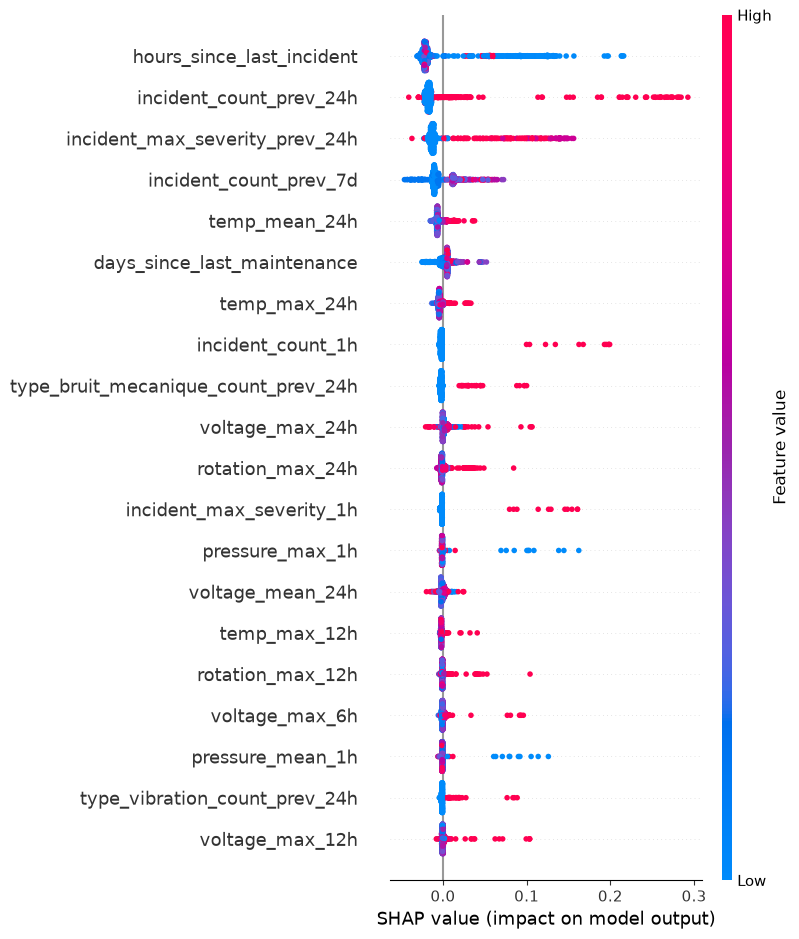

In [ ]:
import shap
import mlflow
from sklearn.pipeline import Pipeline

# rend la cellule autonome après un restart du kernel
mlflow.set_tracking_uri('sqlite:///mlflow.db')

# le run (parent) avec la meilleure PR-AUC sur la validation
best_run = (
    mlflow.search_runs(
        experiment_names=['b5-maintenance-predictive'],
        filter_string="tags.model_name != ''",
    )
    .sort_values('metrics.pr_auc', ascending=False)
    .iloc[0]
)
print(f"Meilleur run : {best_run['tags.mlflow.runName']} "
      f"({best_run['tags.model_name']}) — PR-AUC = {best_run['metrics.pr_auc']:.4f}")

model_uri = f"runs:/{best_run.run_id}/model"
try:
    best_model = mlflow.sklearn.load_model(model_uri)
except mlflow.exceptions.MlflowException:
    best_model = mlflow.xgboost.load_model(model_uri)

# échantillon de la validation pour garder un temps de calcul raisonnable
X_shap = X_val[feature_cols].sample(n=min(1000, len(X_val)), random_state=42)

if isinstance(best_model, Pipeline):
    # régression logistique : on explique le modèle final sur les données standardisées
    X_expl = pd.DataFrame(
        best_model[:-1].transform(X_shap), columns=feature_cols, index=X_shap.index,
    )
    explainer = shap.LinearExplainer(best_model[-1], X_expl)
else:
    # Random Forest / XGBoost
    X_expl = X_shap
    explainer = shap.TreeExplainer(best_model)

shap_values = explainer(X_expl)
if shap_values.values.ndim == 3:  # Random Forest : une sortie par classe, on garde la classe "panne"
    shap_values = shap_values[..., 1]

shap.summary_plot(shap_values, X_expl, max_display=20)

# Explicabilité d'une prédiction de panne tirée du jeu de test

Ligne 25800 — vraie étiquette : panne sous 24h = True
Prédiction du modèle : proba de panne = 0.989


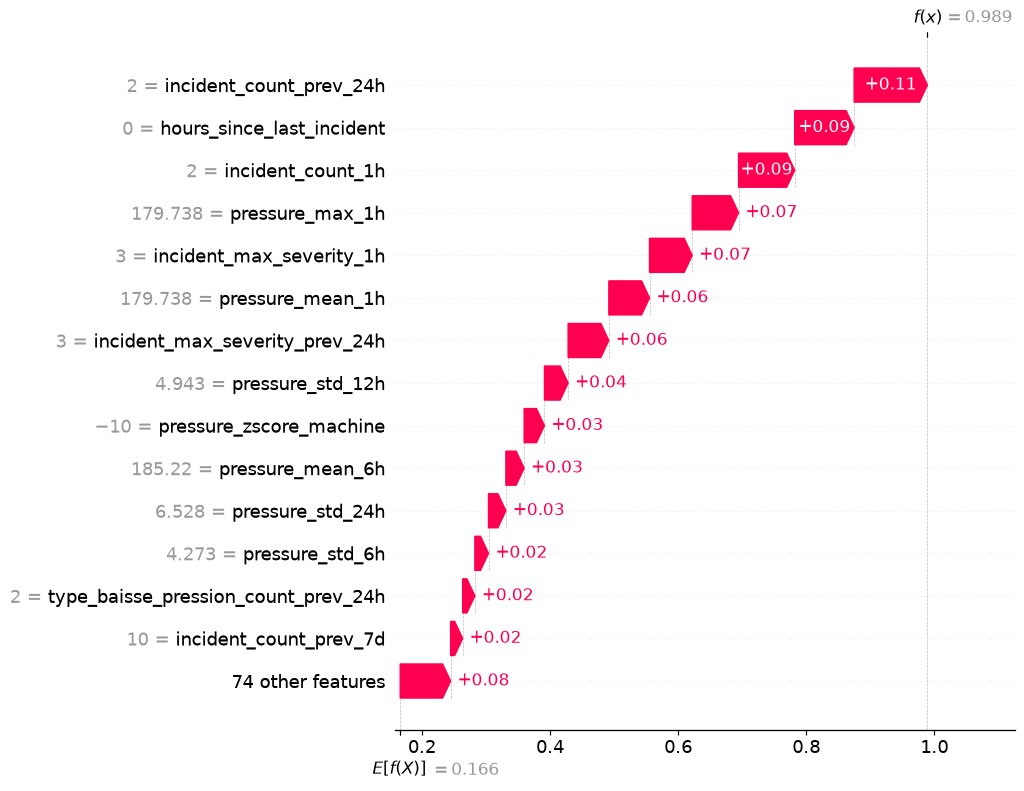

In [ ]:
# on prend dans le test une vraie panne que le modèle détecte avec la proba la plus haute
proba_test = pd.Series(
    best_model.predict_proba(X_test[feature_cols])[:, 1], index=X_test.index,
)
idx = proba_test[y_test == True].idxmax()
row = X_test.loc[[idx], feature_cols]

print(f'Ligne {idx} — vraie étiquette : panne sous 24h = {y_test.loc[idx]}')
print(f'Prédiction du modèle : proba de panne = {proba_test.loc[idx]:.3f}')

# explication SHAP de cette seule prédiction
if isinstance(best_model, Pipeline):
    row_expl = pd.DataFrame(
        best_model[:-1].transform(row), columns=feature_cols, index=row.index,
    )
else:
    row_expl = row

explanation = explainer(row_expl)
if explanation.values.ndim == 3:  # Random Forest : on garde la classe "panne"
    explanation = explanation[..., 1]

shap.waterfall_plot(explanation[0], max_display=15)

# On explique avec un force_plot sur le set de test

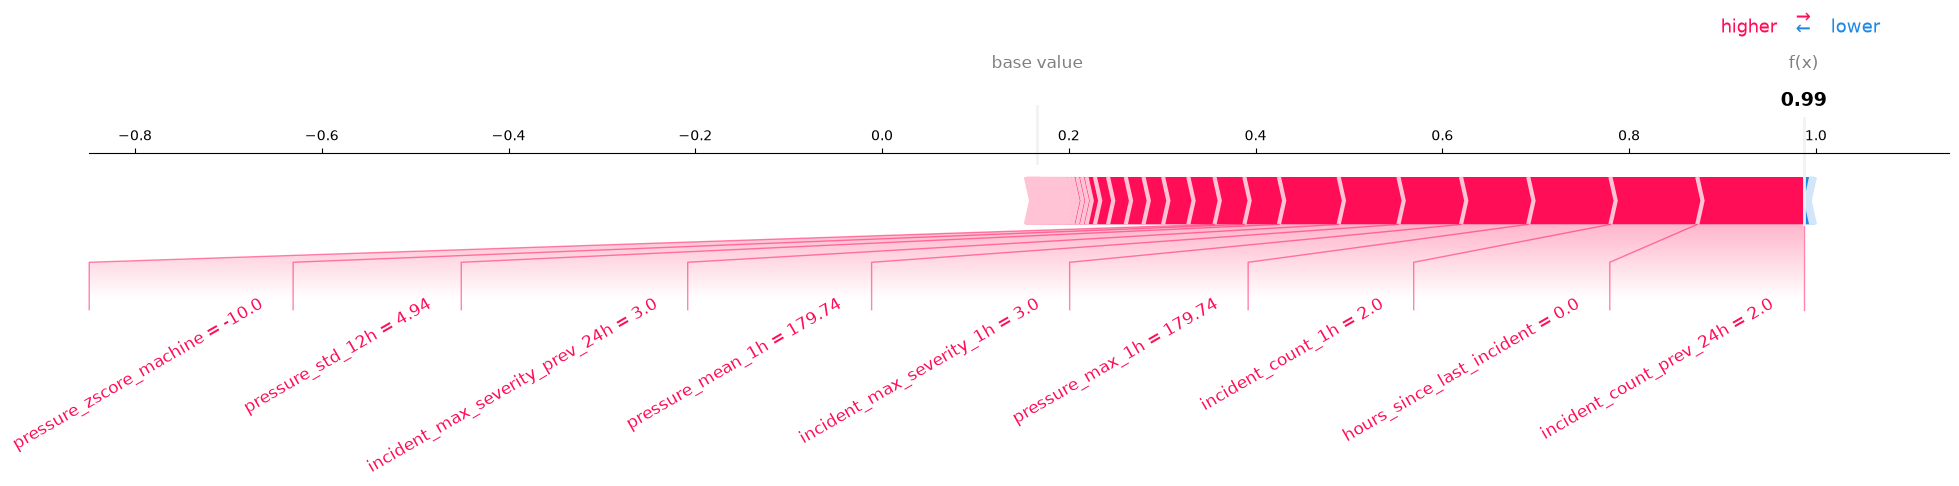

In [ ]:
# force_plot : même explication que le waterfall, vue en "tir à la corde" autour de la valeur de base
shap.force_plot(
    explanation[0].base_values,
    explanation[0].values.round(3),
    row_expl.iloc[0].round(2),      # valeurs arrondies pour des libellés lisibles
    matplotlib=True,
    figsize=(24, 4),
    text_rotation=30,               # libellés en biais pour éviter les chevauchements
    contribution_threshold=0.04,    # ne montre que les features qui pèsent vraiment
)

# Comparaison du meilleur Random Forest avec le meilleur XGBoost

In [ ]:
best_rf_run = (
    mlflow.search_runs(
        experiment_names=['b5-maintenance-predictive'],
        filter_string="tags.model_name LIKE 'Random Forest%'",
    )
    .sort_values('metrics.pr_auc', ascending=False)
    .iloc[0]
)
best_xgb_run = (
    mlflow.search_runs(
        experiment_names=['b5-maintenance-predictive'],
        filter_string="tags.model_name LIKE 'XGBoost%'",
    )
    .sort_values('metrics.pr_auc', ascending=False)
    .iloc[0]
)

best_rf_vs_xgb = pd.DataFrame([
    {
        'Modèle': run['tags.model_name'],
        'PR-AUC': run['metrics.pr_auc'],
        'ROC-AUC': run['metrics.roc_auc'],
        'Précision': run['metrics.precision'],
        'Rappel': run['metrics.recall'],
        'F1': run['metrics.f1'],
    }
    for run in (best_rf_run, best_xgb_run)
]).sort_values('PR-AUC', ascending=False).reset_index(drop=True)

best_rf_vs_xgb

,Modèle,PR-AUC,ROC-AUC,Précision,Rappel,F1
0,Random Forest (GridSearchCV),0.603289,0.746578,0.898473,0.338998,0.492263
1,XGBoost max depth 3,0.594399,0.756376,0.567050,0.511521,0.537856


### Comparaison des features importantes (SHAP)
On charge les deux modèles et on trace leurs `summary_plot` sur le même échantillon de validation, pour voir si Random Forest et XGBoost s'appuient sur les mêmes signaux.

Run ignoré (modèle illisible) : 'XGBoost max depth 3' (1959ff9cf98c4d8f81e5d3254867d48f)


Random Forest (Random Forest (GridSearchCV)) — PR-AUC = 0.6033


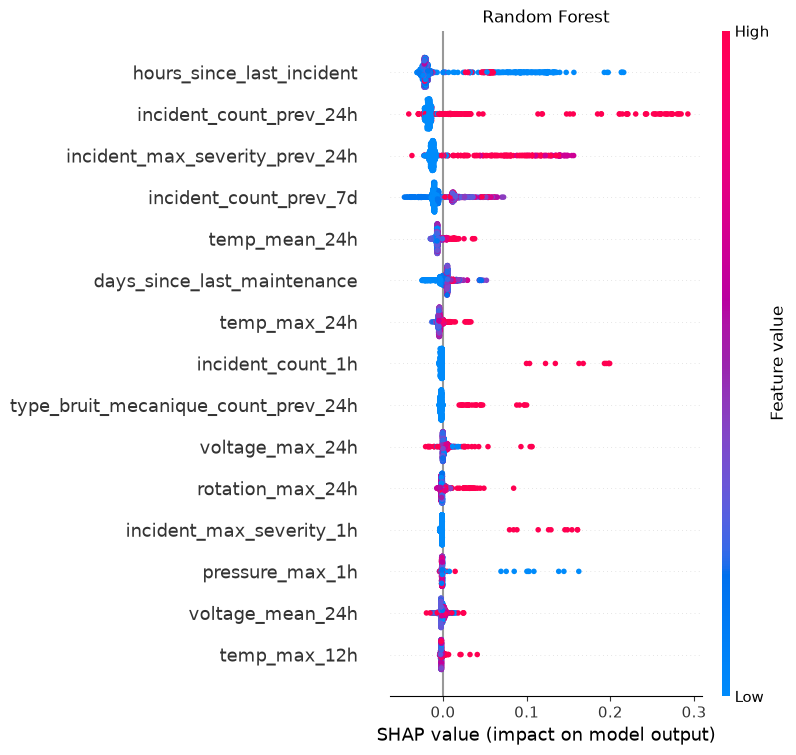

XGBoost (XGBoost (GridSearchCV)) — PR-AUC = 0.5904


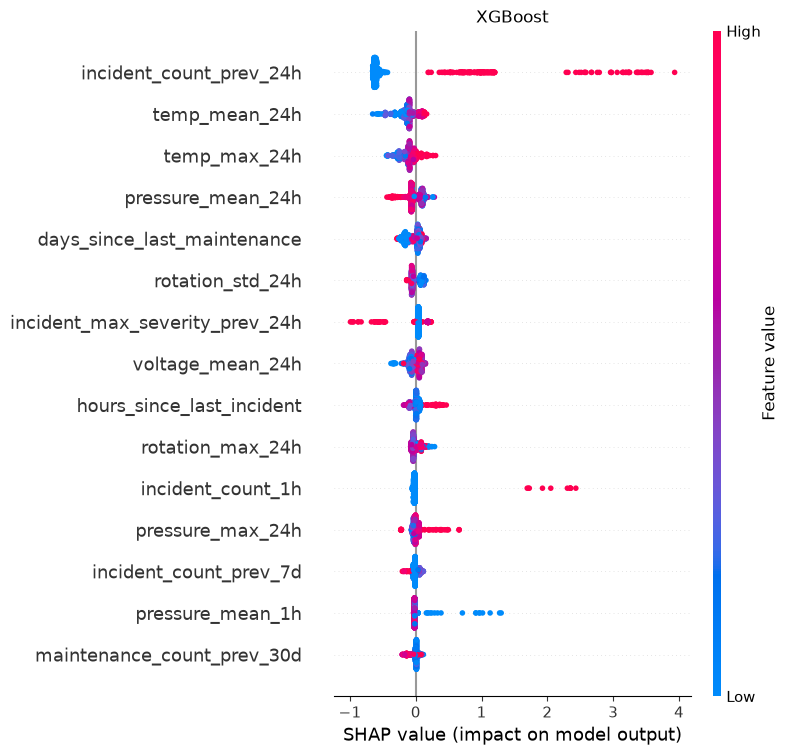

In [ ]:
def load_best_run_model(model_name_pattern):
    """Charge le modèle du meilleur run (par PR-AUC) qui se charge effectivement,
    en sautant les runs éventuellement mal loggés (mauvais flavor, artefact absent)."""
    candidates = mlflow.search_runs(
        experiment_names=['b5-maintenance-predictive'],
        filter_string=f"tags.model_name LIKE '{model_name_pattern}'",
    ).sort_values('metrics.pr_auc', ascending=False)

    for _, run in candidates.iterrows():
        model_uri = f"runs:/{run.run_id}/model"
        for loader in (mlflow.sklearn.load_model, mlflow.xgboost.load_model):
            try:
                model = loader(model_uri)
            except mlflow.exceptions.MlflowException:
                continue
            if hasattr(model, 'predict_proba'):  # écarte les runs où un objet non-modèle a été loggé
                return run, model
        print(f"Run ignoré (modèle illisible) : {run['tags.model_name']!r} ({run.run_id})")

    raise RuntimeError(f"Aucun run chargeable pour le motif {model_name_pattern!r}")

best_rf_run, rf_model = load_best_run_model('Random Forest%')
best_xgb_run, xgb_model = load_best_run_model('XGBoost%')

# même échantillon de validation pour une comparaison équitable
X_shap_cmp = X_val[feature_cols].sample(n=min(1000, len(X_val)), random_state=42)

rf_explainer = shap.TreeExplainer(rf_model)
rf_shap_values = rf_explainer(X_shap_cmp)
if rf_shap_values.values.ndim == 3:  # une sortie par classe : on garde "panne"
    rf_shap_values = rf_shap_values[..., 1]

xgb_explainer = shap.TreeExplainer(xgb_model)
xgb_shap_values = xgb_explainer(X_shap_cmp)

print(f"Random Forest ({best_rf_run['tags.model_name']}) — PR-AUC = {best_rf_run['metrics.pr_auc']:.4f}")
shap.summary_plot(rf_shap_values, X_shap_cmp, max_display=15, show=False)
plt.title('Random Forest')
plt.show()

print(f"XGBoost ({best_xgb_run['tags.model_name']}) — PR-AUC = {best_xgb_run['metrics.pr_auc']:.4f}")
shap.summary_plot(xgb_shap_values, X_shap_cmp, max_display=15, show=False)
plt.title('XGBoost')
plt.show()